To compare the best transformer model's errors against the Assignment 1 baseline, we will quickly retrain the CountVectorizer + Logistic Regression pipeline here to get its test set predictions.

In [1]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from transformers import AutoTokenizer, AutoModel

# Import modular architectures
import sys
sys.path.append('..')
from models.transformers import UniversalTransformerClassifier

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PROCESSED_DIR = '../data/processed'
MODELS_DIR = '../models/saved_weights'
RESULTS_DIR = '../results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# 1. Load Data
train_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'train.csv'))
test_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'test.csv'))

LABEL_COLS = [c for c in train_df.columns if c not in ['Argument ID', 'text_raw', 'text_clean']]
y_train = train_df[LABEL_COLS].values
y_test = test_df[LABEL_COLS].values

# Extract the CLEANED text for the baseline (Lemmatized + Stopwords removed)
X_train_clean = train_df['text_clean'].values
X_test_clean = test_df['text_clean'].values

# Keep the RAW text for the neural model inference and for printing readable errors later
X_test_raw = test_df['text_raw'].values

# 2. Train Assignment 1 Baseline to get comparison predictions
print("Training Baseline...")
baseline_pipe = Pipeline([
    # Matches the Assignment 1 baseline parameters exactly
    ('vec', CountVectorizer(ngram_range=(1, 4), analyzer='word', lowercase=True, min_df=3, max_features=20000)),
    ('clf', OneVsRestClassifier(LogisticRegression(solver='liblinear', random_state=42)))
])

# 3. Fit and predict using the CLEANED text
baseline_pipe.fit(X_train_clean, y_train)
baseline_preds = baseline_pipe.predict(X_test_clean)

print(f"✅ Baseline Test F1-Macro: {f1_score(y_test, baseline_preds, average='macro'):.4f}")

Training Baseline...
✅ Baseline Test F1-Macro: 0.4432


We will load RoBERTa, which proved to be the best model in this project, to perform the error analysis. We use the optimal threshold found in notebook 3 (0.49).

In [2]:
MODEL_NAME = 'roberta-base'
WEIGHTS_FILE = 'roberta_best.pt'

print(f"Loading {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
neural_model = UniversalTransformerClassifier(model_name=MODEL_NAME).to(DEVICE)
neural_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, WEIGHTS_FILE), map_location=DEVICE))
neural_model.eval()

neural_preds = []
print("Running neural inference on test set...")
with torch.no_grad():
    for text in X_test_raw:
        enc = tokenizer(text, truncation=True, padding='max_length', max_length=128, return_tensors='pt')
        input_ids = enc['input_ids'].to(DEVICE)
        mask = enc['attention_mask'].to(DEVICE)
        
        logits = neural_model(input_ids, mask)
        preds = (torch.sigmoid(logits) > 0.49).cpu().numpy()[0]
        neural_preds.append(preds)

neural_preds = np.array(neural_preds)
print(f"✅ Neural Test F1-Macro: {f1_score(y_test, neural_preds, average='macro', zero_division=0):.4f}")

Loading roberta-base...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Running neural inference on test set...
✅ Neural Test F1-Macro: 0.5426


We compare the test F1-score on each label using CountVec+LogReg vs pre-trained RoBERTa

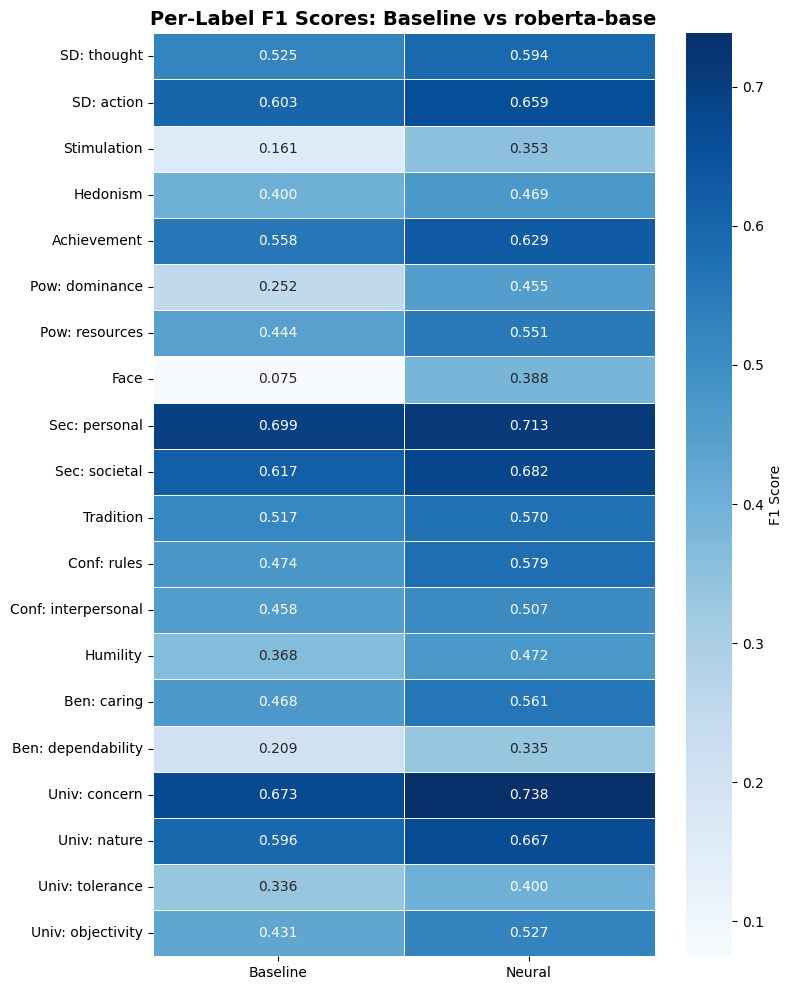

Saved to ../results/per_label_f1_heatmap.png


In [3]:
# Calculate F1 for each label independently
label_data = []
for i, label in enumerate(LABEL_COLS):
    bl_f1 = f1_score(y_test[:, i], baseline_preds[:, i], zero_division=0)
    nn_f1 = f1_score(y_test[:, i], neural_preds[:, i], zero_division=0)
    label_data.append({'Label': label, 'Baseline': bl_f1, 'Neural': nn_f1})

f1_df = pd.DataFrame(label_data).set_index('Label')

# Shorten labels for a cleaner plot
f1_df.index = [l.replace('Universalism: ', 'Univ: ').replace('Self-direction: ', 'SD: ')
               .replace('Benevolence: ', 'Ben: ').replace('Conformity: ', 'Conf: ')
               .replace('Security: ', 'Sec: ').replace('Power: ', 'Pow: ') 
               for l in f1_df.index]

plt.figure(figsize=(8, 10))
sns.heatmap(f1_df, annot=True, fmt='.3f', cmap='Blues', linewidths=0.5, cbar_kws={'label': 'F1 Score'})
plt.title(f'Per-Label F1 Scores: Baseline vs {MODEL_NAME}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'per_label_f1_heatmap.png'), dpi=150)
plt.show()
print(f"Saved to {RESULTS_DIR}/per_label_f1_heatmap.png")

We check examples on which the Transformer beats the Baseline and viceversa

In [4]:
print("\n--- 🔍 EXAMPLES WHERE TRANSFORMER MODEL FIXED BASELINE ERRORS ---")
fixed_count = 0
for i in range(len(X_test_raw)):
    if fixed_count >= 3: break
        
    bl_wrong = (baseline_preds[i] != y_test[i])
    nn_right = (neural_preds[i] == y_test[i])
    fixed_mask = bl_wrong & nn_right
    
    if fixed_mask.any():
        fixed_count += 1
        fixed_labels = [LABEL_COLS[j] for j in range(20) if fixed_mask[j]]
        print(f"\nExample {fixed_count}:")
        print(f"Text: {X_test_raw[i][:200]}...")
        print(f"Ground Truth: {[LABEL_COLS[j] for j in range(20) if y_test[i][j]==1]}")
        print(f"Baseline (Wrong): {[LABEL_COLS[j] for j in range(20) if baseline_preds[i][j]==1]}")
        print(f"Neural (Right):   {[LABEL_COLS[j] for j in range(20) if neural_preds[i][j]==1]}")
        print(f"-> Labels Fixed:  {fixed_labels}")

print("\n--- ⚠️ EXAMPLES WHERE NEURAL MODEL INTRODUCED NEW ERRORS ---")
new_error_count = 0
for i in range(len(X_test_raw)):
    if new_error_count >= 3: break
        
    bl_right = (baseline_preds[i] == y_test[i])
    nn_wrong = (neural_preds[i] != y_test[i])
    introduced_mask = bl_right & nn_wrong
    
    if introduced_mask.any():
        new_error_count += 1
        err_labels = [LABEL_COLS[j] for j in range(20) if introduced_mask[j]]
        print(f"\nExample {new_error_count}:")
        print(f"Text: {X_test_raw[i][:200]}...")
        print(f"Ground Truth: {[LABEL_COLS[j] for j in range(20) if y_test[i][j]==1]}")
        print(f"Baseline (Right): {[LABEL_COLS[j] for j in range(20) if baseline_preds[i][j]==1]}")
        print(f"Neural (Wrong):   {[LABEL_COLS[j] for j in range(20) if neural_preds[i][j]==1]}")
        print(f"-> Labels Missed/Hallucinated: {err_labels}")


--- 🔍 EXAMPLES WHERE TRANSFORMER MODEL FIXED BASELINE ERRORS ---

Example 1:
Text: We should adopt an austerity regime [SEP] in favor of [SEP] we should adopt an austerity regime because it is unfair to expect future generations to settle the debts that we run up...
Ground Truth: ['Security: personal', 'Security: societal', 'Benevolence: dependability']
Baseline (Wrong): ['Power: dominance', 'Power: resources', 'Security: personal', 'Universalism: concern']
Neural (Right):   ['Power: resources', 'Security: personal', 'Security: societal', 'Benevolence: dependability']
-> Labels Fixed:  ['Power: dominance', 'Security: societal', 'Benevolence: dependability', 'Universalism: concern']

Example 2:
Text: We should subsidize Wikipedia [SEP] against [SEP] wikipedia can form biased opinions on topics or misinform the general public and therefore should not be subsidized...
Ground Truth: ['Self-direction: thought', 'Universalism: objectivity']
Baseline (Wrong): ['Face', 'Universalism: objectiv

To see how the model interprets the human values, we extract the attention weights. We build a temporary wrapper with output_attentions=True on, load our weights into it, and plot the attention of the [CLS] token across the sentence.

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


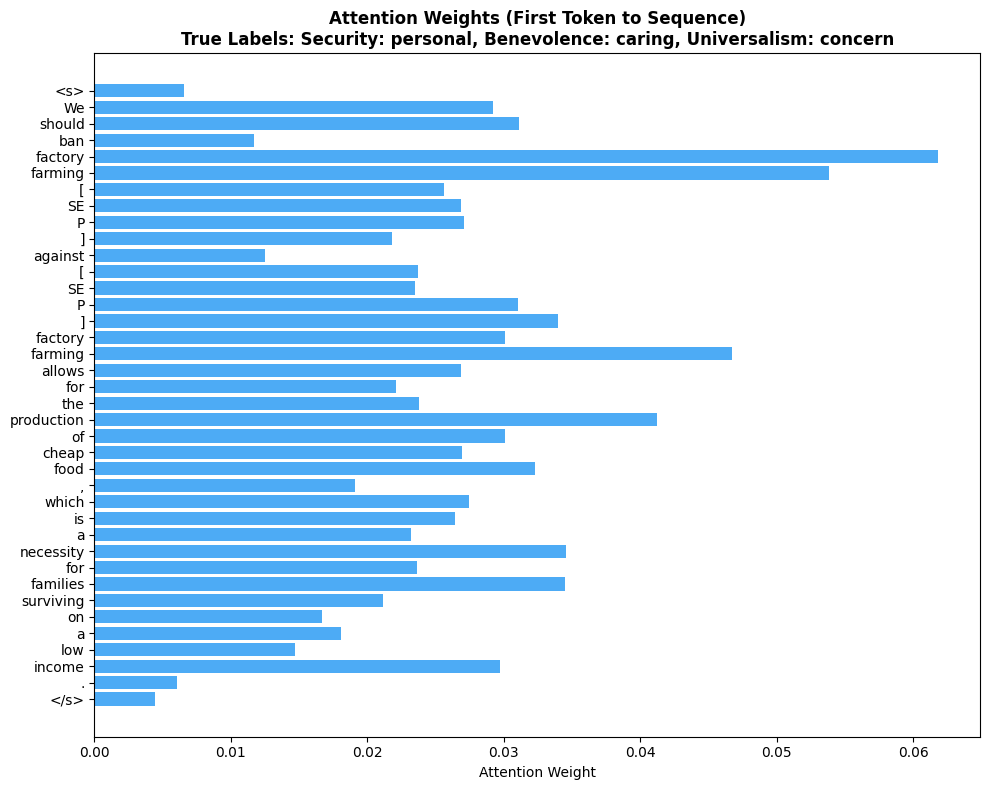

Saved to results/attention_visualizations/example_1.png


In [7]:
import torch.nn as nn

class TransformerWithAttention(nn.Module):
    def __init__(self, model_name=MODEL_NAME, n_classes=20):
        super().__init__()
        # FORCE output_attentions=True
        self.transformer = AutoModel.from_pretrained(model_name, output_attentions=True)
        self.fc = nn.Linear(self.transformer.config.hidden_size, n_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        attentions = outputs.attentions # Tuple of layer attentions
        return self.fc(cls_output), attentions

# Load weights into the attention wrapper
attn_model = TransformerWithAttention(MODEL_NAME).to(DEVICE)
# We use strict=False because our wrapper doesn't have the Dropout layer, but we only need the transformer weights
attn_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, WEIGHTS_FILE), map_location=DEVICE), strict=False)
attn_model.eval()

# Pick the first test example
text = X_test_raw[0]
true_labels = [LABEL_COLS[j] for j in range(20) if y_test[0][j] == 1]

enc = tokenizer(text, truncation=True, max_length=64, return_tensors='pt')
input_ids = enc['input_ids'].to(DEVICE)
mask = enc['attention_mask'].to(DEVICE)
tokens = tokenizer.convert_ids_to_tokens(enc['input_ids'][0])

with torch.no_grad():
    _, attentions = attn_model(input_ids, mask)

# Extract attention from the LAST layer, average across all heads
# attentions[-1] shape: (batch_size, num_heads, seq_len, seq_len)
last_layer_attn = attentions[-1][0].mean(dim=0) 

# Get attention from the first token (Index 0: <s> or [CLS]) to all other tokens
cls_attn = last_layer_attn[0].cpu().numpy()

# Trim padding
n_tokens = mask.sum().item()
cls_attn = cls_attn[:n_tokens]

# Clean up RoBERTa's Byte-Level BPE spaces (the 'Ġ') for the plot
display_tokens = [t.replace('Ġ', '') for t in tokens[:n_tokens]]

# Plot
plt.figure(figsize=(10, 8))
# Swapped to a crisp blue palette for a cleaner look
plt.barh(range(len(display_tokens)), cls_attn, color='#2196F3', alpha=0.8)
plt.yticks(range(len(display_tokens)), display_tokens, fontsize=10)
plt.gca().invert_yaxis() # Read top to bottom
plt.title(f'Attention Weights (First Token to Sequence)\nTrue Labels: {", ".join(true_labels)}', fontweight='bold')
plt.xlabel('Attention Weight')
plt.tight_layout()

os.makedirs(os.path.join(RESULTS_DIR, 'attention_visualizations'), exist_ok=True)
plt.savefig(os.path.join(RESULTS_DIR, 'attention_visualizations', 'example_1.png'), dpi=150)
plt.show()
print("Saved to results/attention_visualizations/example_1.png")